## Phase:2 - EDA, Modelling, and Evaluation

---

**We will peform the following operations ini this phase:**
- Load the enriched dataset generated by Notebook 1
- Explore the data thoroughly through visualisations and statistics
- Detect and treat outliers
- Prepare the data for machine learning (preprocessing)
- Train and compare seven standard classifiers
- Tune the best two models and combine them into an ensemble
- Evaluate on a held-out test set using multiple metrics
- Save the trained model for the GUI in the next phase.

---

---
## Import Libraries

We import the libraries that will be used throughout this notebook:
- **numpy** — array mathematics
- **pandas** — data tables
- **scipy.stats** — statistical tests
- **matplotlib.pyplot** — drawing charts
- **seaborn** — statistical charts built on matplotlib
- **pickle** — loading saved Python objects from files
- **sklearn** — all machine learning tools: preprocessing, models, metrics etc


In [491]:
import numpy as np
import pandas as pd
import pickle
import warnings
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

In [492]:
df = pd.read_csv('cardiac_dataset_base.csv')

with open('cardiac_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

CLASS_NAMES  = meta['class_names']
CLASS_COLORS = meta['class_colors']
CONT_COLS    = meta['cont_cols']
CAT_COLS     = meta['cat_cols']
ALL_COLS     = meta['all_cols']
PALETTE      = dict(zip(CLASS_NAMES, CLASS_COLORS))

CONT_NICE = {
    'age': 'Age (yr)',
    'bmi': 'BMI (kg/m²)',
    'systolic_bp': 'Systolic BP (mmHg)',
    'ldl': 'LDL (mg/dL)',
    'fasting_glucose': 'Fasting Glucose (mg/dL)',
    'heart_rate': 'Heart Rate (bpm)',
    'spo2': 'SpO₂ (%)',
    'ejection_fraction': 'Ejection Fraction (%)',
    'bnp': 'BNP (pg/mL)'
}

CAT_NICE = {
    'sob': 'Shortness of Breath',
    'chest_tightness': 'Chest Tightness on Exertion',
    'smoking': 'Smoking Status',
    'diabetes': 'Diabetes Status',
    'edema': 'Leg Edema',
    'palpitations': 'Palpitations',
    'ecg': 'ECG Heart Rhythm'
}

CAT_LABELS = {
    'sob':             {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'},
    'chest_tightness': {0: 'None', 1: 'Mild', 2: 'Clear'},
    'smoking':         {0: 'Never', 1: 'Light', 2: 'Moderate', 3: 'Heavy'},
    'diabetes':        {0: 'Normal', 1: 'Pre-DM', 2: 'Type2', 3: 'Type1'},
    'edema':           {0: 'None', 1: 'Mild', 2: 'Severe'},
    'palpitations':    {0: 'None', 1: 'Occasional', 2: 'Frequent'},
    'ecg':             {0: 'Normal', 1: 'Tachy/Brady', 2: 'AF', 3: 'VT'}
}

print('Dataset loaded.')
print('Shape:', df.shape, '— rows = patients, columns = features + labels')
print('Classes:', CLASS_NAMES)
df.head()

Dataset loaded.
Shape: (16000, 17) — rows = patients, columns = features + labels
Classes: ['Healthy', 'CAD', 'Arrhythmia', 'Heart Failure']


,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg,target
0,49.804697,41.827144,120.913509,78.776072,113.123345,124.284288,92.602669,50.428114,55.338655,0,0,0,2,1,2,2,Arrhythmia
1,47.093524,23.366043,161.318483,203.325521,107.009766,69.731829,88.754825,52.340943,137.329995,2,1,0,2,0,0,0,CAD
2,57.055232,34.272785,121.676649,147.035969,168.406677,63.087338,94.482808,55.947684,69.205694,1,0,0,1,0,0,2,CAD
3,31.105146,25.011601,121.508877,121.794937,104.666318,88.940203,98.025287,73.113482,74.763969,0,0,0,1,0,0,1,Healthy
4,80.576425,35.732129,135.696282,205.529348,111.758944,94.218927,91.709910,54.500183,182.641657,2,1,2,2,1,1,1,Arrhythmia


In [493]:
df.shape

(16000, 17)

In [494]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate',
       'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking',
       'diabetes', 'edema', 'palpitations', 'ecg', 'target'],
      dtype='object')

In [495]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                16000 non-null  float64
 1   bmi                16000 non-null  float64
 2   systolic_bp        16000 non-null  float64
 3   ldl                16000 non-null  float64
 4   fasting_glucose    16000 non-null  float64
 5   heart_rate         16000 non-null  float64
 6   spo2               16000 non-null  float64
 7   ejection_fraction  16000 non-null  float64
 8   bnp                16000 non-null  float64
 9   sob                16000 non-null  int64  
 10  chest_tightness    16000 non-null  int64  
 11  smoking            16000 non-null  int64  
 12  diabetes           16000 non-null  int64  
 13  edema              16000 non-null  int64  
 14  palpitations       16000 non-null  int64  
 15  ecg                16000 non-null  int64  
 16  target             160

In [496]:
df.describe()

,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.00000,16000.000000,16000.000000,16000.000000,16000.000000
mean,57.989279,31.034066,141.867550,146.089597,141.102785,87.069622,93.701373,56.244339,224.448179,0.987750,0.649000,0.78125,0.884750,0.476250,0.940688,1.203375
std,13.077797,5.364806,19.220081,40.275196,47.548168,21.072263,3.454869,8.721005,312.667759,0.976299,0.761387,0.97594,1.001202,0.697919,0.741252,1.036861
min,20.036064,17.081336,100.003345,48.197703,70.001619,38.105011,82.040928,32.051730,5.037276,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,48.970887,27.155747,127.206695,116.987562,104.381611,72.569893,91.385408,50.357369,56.727409,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,58.376766,30.984380,140.744018,144.378365,130.923708,84.086285,94.164152,56.713681,130.603817,1.000000,0.000000,0.00000,1.000000,0.000000,1.000000,1.000000
75%,67.442785,34.841617,156.022486,173.317954,165.846331,97.928646,96.470567,62.627568,257.296401,2.000000,1.000000,1.00000,2.000000,1.000000,1.000000,2.000000
max,89.970870,43.998119,191.951960,264.488056,309.983915,164.554051,99.991196,75.931897,2991.427548,3.000000,2.000000,3.00000,3.000000,2.000000,2.000000,3.000000


In [497]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                16000 non-null  float64
 1   bmi                16000 non-null  float64
 2   systolic_bp        16000 non-null  float64
 3   ldl                16000 non-null  float64
 4   fasting_glucose    16000 non-null  float64
 5   heart_rate         16000 non-null  float64
 6   spo2               16000 non-null  float64
 7   ejection_fraction  16000 non-null  float64
 8   bnp                16000 non-null  float64
 9   sob                16000 non-null  int64  
 10  chest_tightness    16000 non-null  int64  
 11  smoking            16000 non-null  int64  
 12  diabetes           16000 non-null  int64  
 13  edema              16000 non-null  int64  
 14  palpitations       16000 non-null  int64  
 15  ecg                16000 non-null  int64  
 16  target             160

In [498]:
df.head()

,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg,target
0,49.804697,41.827144,120.913509,78.776072,113.123345,124.284288,92.602669,50.428114,55.338655,0,0,0,2,1,2,2,Arrhythmia
1,47.093524,23.366043,161.318483,203.325521,107.009766,69.731829,88.754825,52.340943,137.329995,2,1,0,2,0,0,0,CAD
2,57.055232,34.272785,121.676649,147.035969,168.406677,63.087338,94.482808,55.947684,69.205694,1,0,0,1,0,0,2,CAD
3,31.105146,25.011601,121.508877,121.794937,104.666318,88.940203,98.025287,73.113482,74.763969,0,0,0,1,0,0,1,Healthy
4,80.576425,35.732129,135.696282,205.529348,111.758944,94.218927,91.709910,54.500183,182.641657,2,1,2,2,1,1,1,Arrhythmia


In [499]:
df.isnull().sum()

age                  0
bmi                  0
systolic_bp          0
ldl                  0
fasting_glucose      0
heart_rate           0
spo2                 0
ejection_fraction    0
bnp                  0
sob                  0
chest_tightness      0
smoking              0
diabetes             0
edema                0
palpitations         0
ecg                  0
target               0
dtype: int64

In [500]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [age, bmi, systolic_bp, ldl, fasting_glucose, heart_rate, spo2, ejection_fraction, bnp, sob, chest_tightness, smoking, diabetes, edema, palpitations, ecg, target]
Index: []


In [501]:
print(' Summary Statistics per Class')
display(df.groupby('target')[CONT_COLS].agg(['mean', 'std', 'min', 'max']).round(2))

 Summary Statistics per Class


age                         bmi                      \
                mean    std    min    max   mean   std    min    max   
target                                                                 
Arrhythmia     58.01  13.03  28.01  87.90  31.12  5.05  20.06  42.00   
CAD            60.72   9.51  40.08  81.98  32.97  5.08  22.01  44.00   
Healthy        48.12  12.05  20.04  74.90  29.18  4.56  18.50  40.00   
Heart Failure  65.10  11.10  40.01  89.97  30.87  5.98  17.08  43.98   

              systolic_bp         ...   spo2        ejection_fraction        \
                     mean    std  ...    min    max              mean   std   
target                            ...                                         
Arrhythmia         144.97  16.34  ...  86.02  98.99             53.80  8.01   
CAD                152.58  15.51  ...  88.00  99.00             51.22  8.65   
Healthy            124.24  10.58  ...  94.00  99.99             62.04  6.12   
Heart Failure      145.68  20.22  ...  82.04  98.99             57.91  7.75   

                                bnp                          
                 min    max    mean     std    min      max  
target                                                       
Arrhythmia     35.09  71.99  145.29  112.95  20.12   594.10  
CAD            32.05  69.97  211.20  109.40  60.00   579.60  
Healthy        48.04  75.93   43.17   36.18   5.04   199.19  
Heart Failure  40.01  74.99  498.13  500.85  35.06  2991.43  

[4 rows x 36 columns]

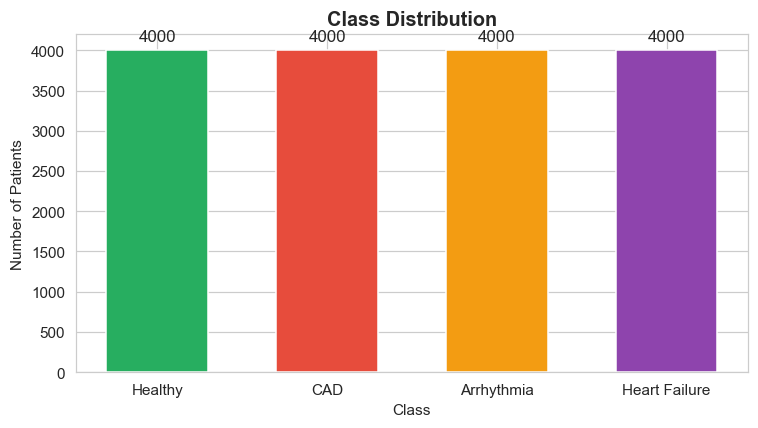

In [502]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['target'].value_counts().reindex(CLASS_NAMES)
bars = ax.bar(counts.index, counts.values, color=CLASS_COLORS, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

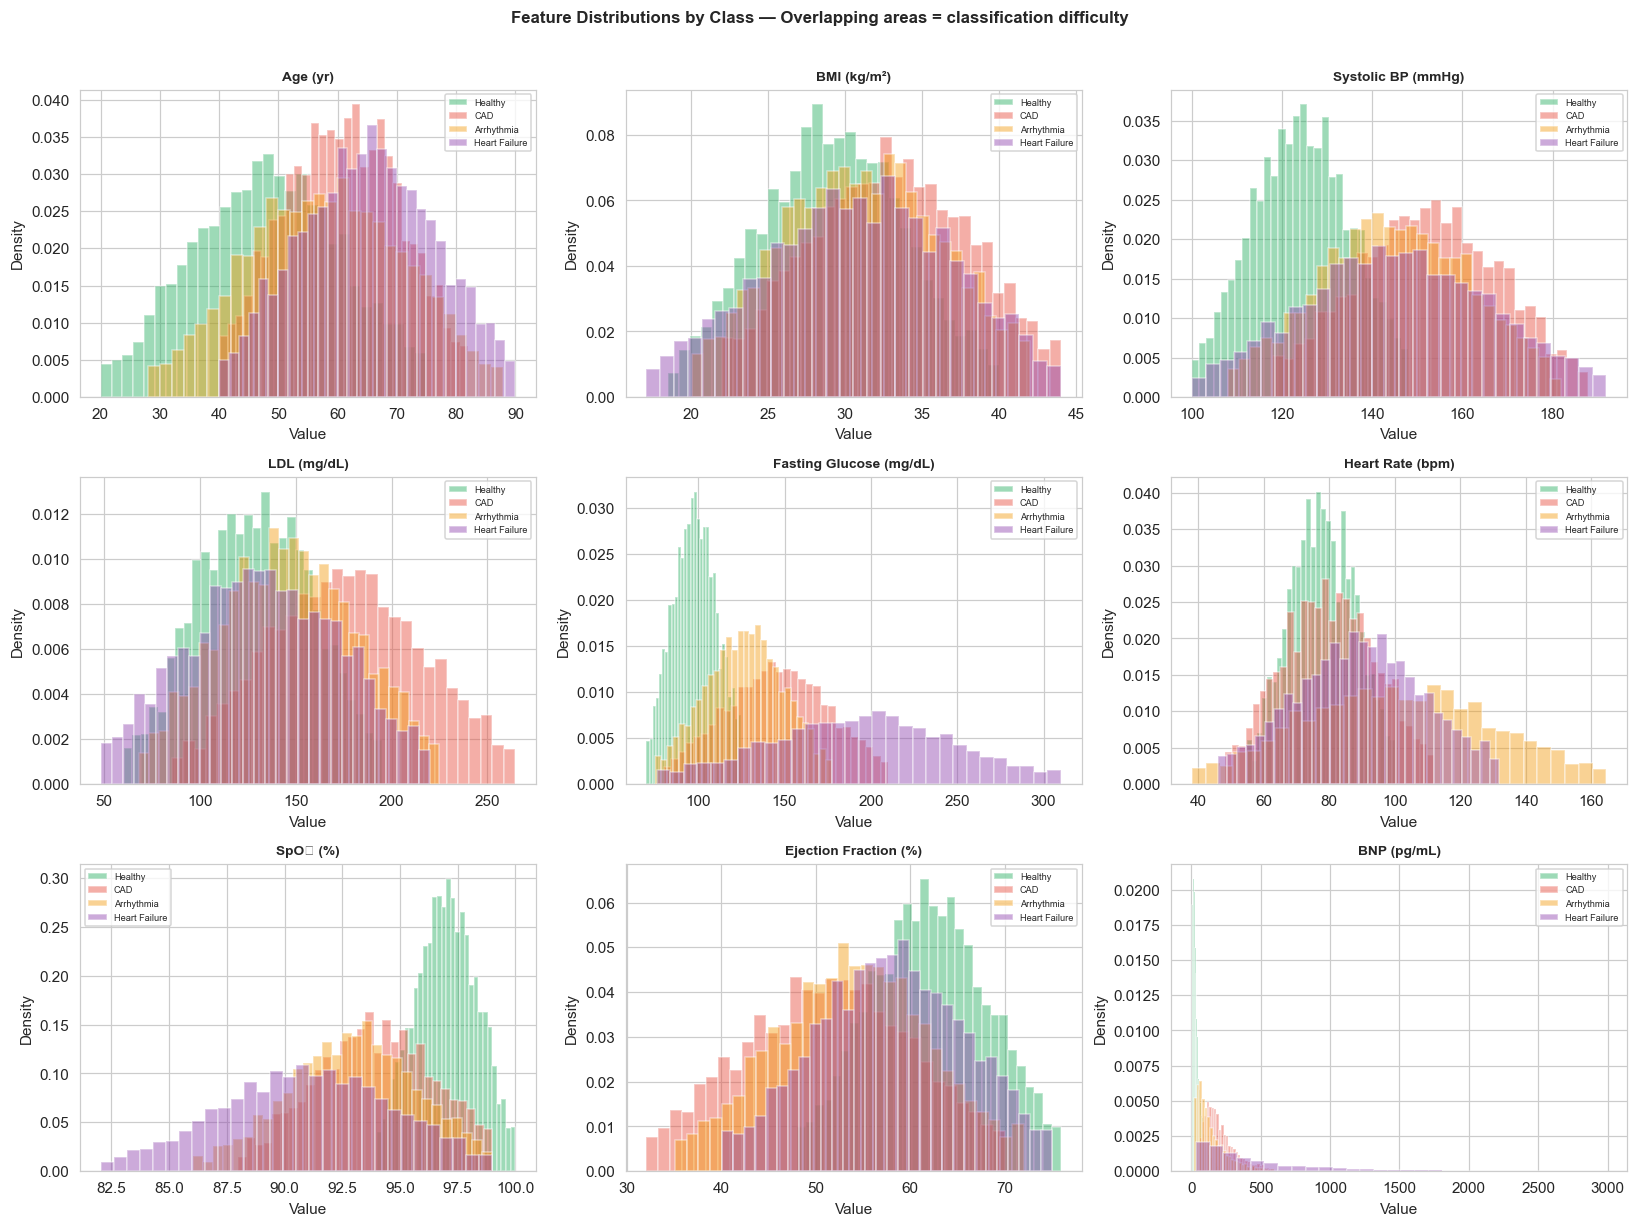

In [503]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
        subset = df.loc[df['target'] == cls, feat]
        axes[i].hist(subset, bins=30, alpha=0.45, color=col, label=cls, density=True)
    axes[i].set_title(CONT_NICE[feat], fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=6)

fig.suptitle('Feature Distributions by Class — Overlapping areas = classification difficulty',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

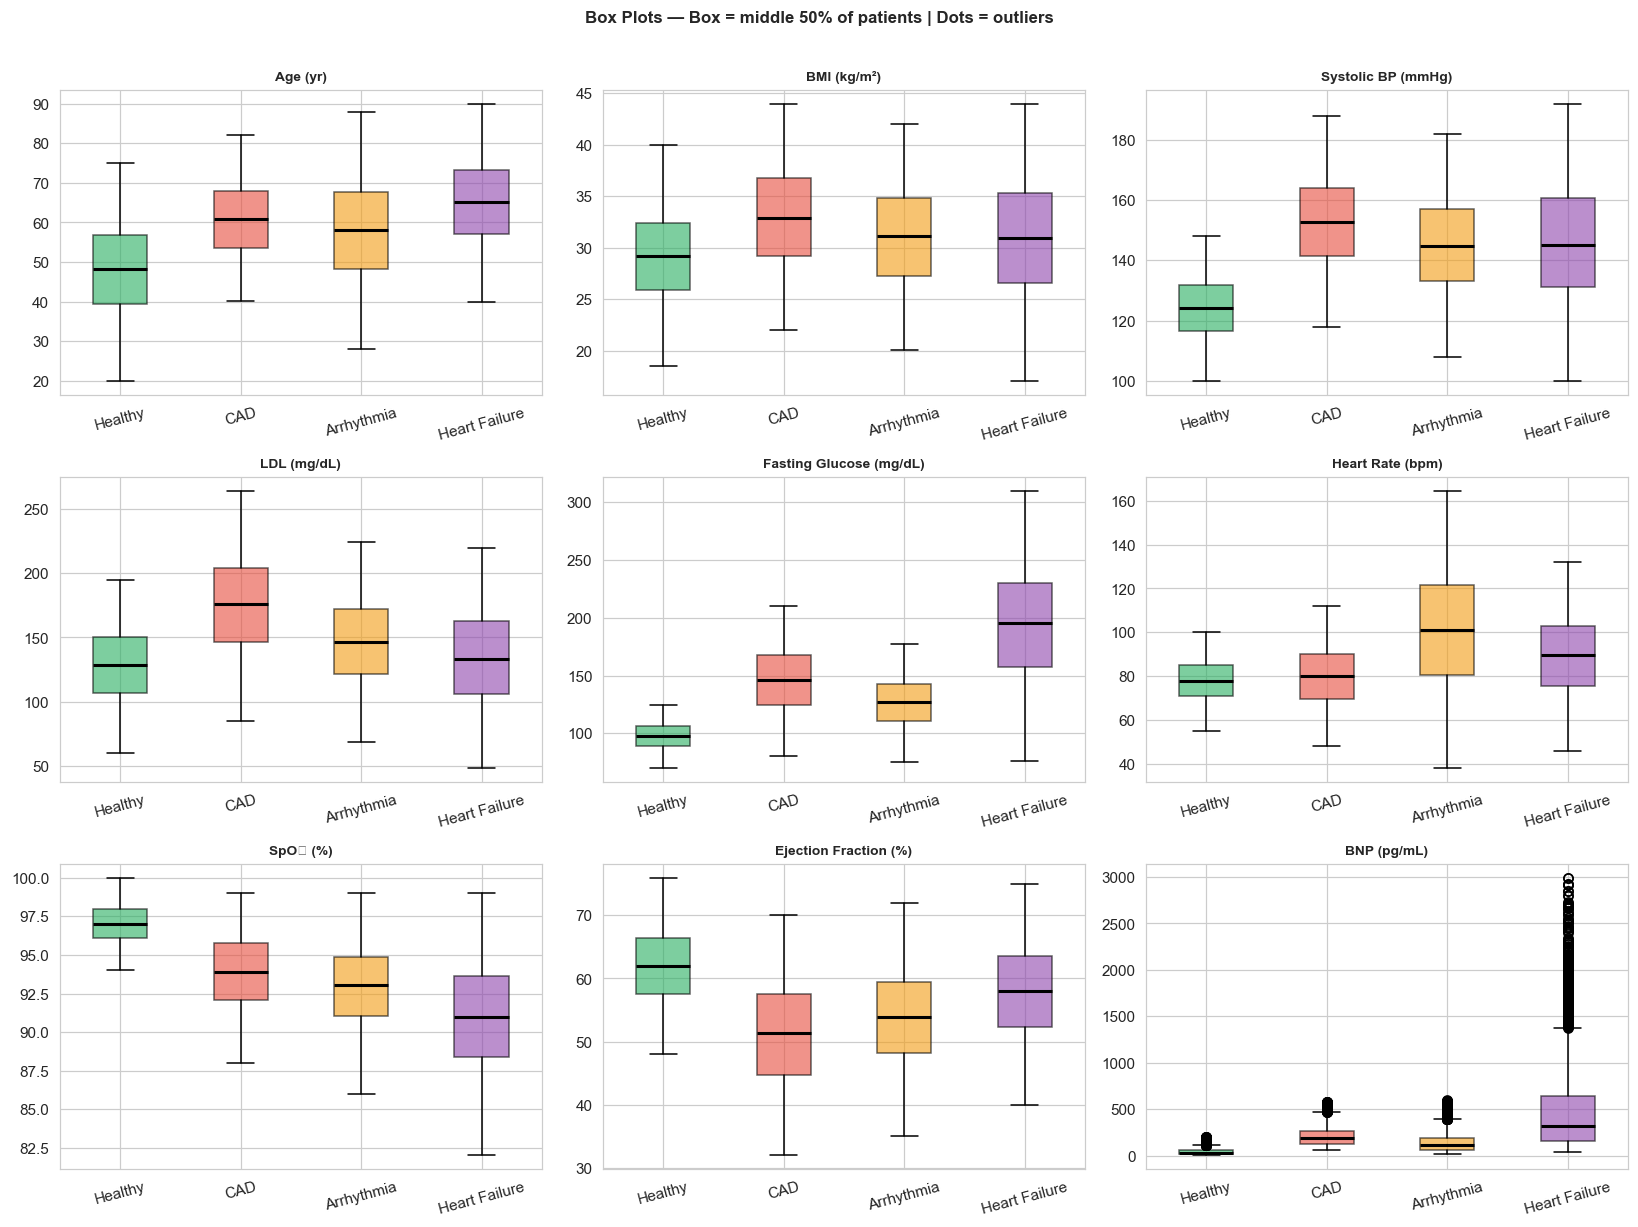

In [504]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    data_list = [df.loc[df['target'] == cls, feat].values for cls in CLASS_NAMES]
    bp = axes[i].boxplot(data_list, patch_artist=True, labels=CLASS_NAMES,
                         medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)
    axes[i].set_title(CONT_NICE[feat], fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

fig.suptitle('Box Plots — Box = middle 50% of patients | Dots = outliers',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [505]:
print('=== Outlier Detection (IQR Method) ===')
print('Feature                   Outliers   % of data   Lower Fence   Upper Fence')
print('-' * 72)

outlier_report = []
for feat in CONT_COLS:
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lo_fence = Q1 - 1.5 * IQR
    hi_fence = Q3 + 1.5 * IQR
    mask  = (df[feat] < lo_fence) | (df[feat] > hi_fence)
    n_out = mask.sum()
    pct   = round(100 * n_out / len(df), 2)
    outlier_report.append({
        'Feature': feat, 'Outliers': n_out, 'Pct': pct,
        'LowerFence': round(lo_fence, 2), 'UpperFence': round(hi_fence, 2)
    })
    print(' ', feat.ljust(24), str(n_out).ljust(10), str(pct).ljust(12),
          str(round(lo_fence, 1)).ljust(13), str(round(hi_fence, 1)))

=== Outlier Detection (IQR Method) ===
Feature                   Outliers   % of data   Lower Fence   Upper Fence
------------------------------------------------------------------------
  age                      18         0.11         21.3          95.2
  bmi                      0          0.0          15.6          46.4
  systolic_bp              0          0.0          84.0          199.2
  ldl                      42         0.26         32.5          257.8
  fasting_glucose          458        2.86         12.2          258.0
  heart_rate               491        3.07         34.5          136.0
  spo2                     105        0.66         83.8          104.1
  ejection_fraction        0          0.0          32.0          81.0
  bnp                      1225       7.66         -244.1        558.1


In [506]:
import numpy as np

df_clean = df.copy()

# HARD MEDICAL VALIDITY RULES
df_clean = df_clean[
    (df_clean['bnp'] > 0) &
    (df_clean['heart_rate'].between(20, 250)) &
    (df_clean['fasting_glucose'].between(40, 600))
]

# IQR WINSORIZATION 
num_cols = df_clean.select_dtypes(include='number').columns

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if col == 'bnp':
        lower = 1  # BNP cannot be <= 0

    if col == 'heart_rate':
        lower = max(lower, 20)

    if col == 'fasting_glucose':
        lower = max(lower, 40)

    df_clean[col] = df_clean[col].clip(lower, upper)

In [507]:
print(" Data Summary After outlier treatment")

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    print(
        col,
        "| min:", round(df_clean[col].min(), 2),
        "| max:", round(df_clean[col].max(), 2),
        "| outliers:", int(mask.sum())
    )

df = df_clean.copy()

 Data Summary After outlier treatment
age | min: 21.26 | max: 89.97 | outliers: 0
bmi | min: 17.08 | max: 44.0 | outliers: 0
systolic_bp | min: 100.0 | max: 191.95 | outliers: 0
ldl | min: 48.2 | max: 257.81 | outliers: 0
fasting_glucose | min: 70.0 | max: 258.04 | outliers: 0
heart_rate | min: 38.11 | max: 135.97 | outliers: 0
spo2 | min: 83.76 | max: 99.99 | outliers: 0
ejection_fraction | min: 32.05 | max: 75.93 | outliers: 0
bnp | min: 5.04 | max: 558.15 | outliers: 0
sob | min: 0 | max: 3 | outliers: 0
chest_tightness | min: 0 | max: 2 | outliers: 0
smoking | min: 0.0 | max: 2.5 | outliers: 0
diabetes | min: 0 | max: 3 | outliers: 0
edema | min: 0 | max: 2 | outliers: 0
palpitations | min: 0 | max: 2 | outliers: 0
ecg | min: 0 | max: 3 | outliers: 0


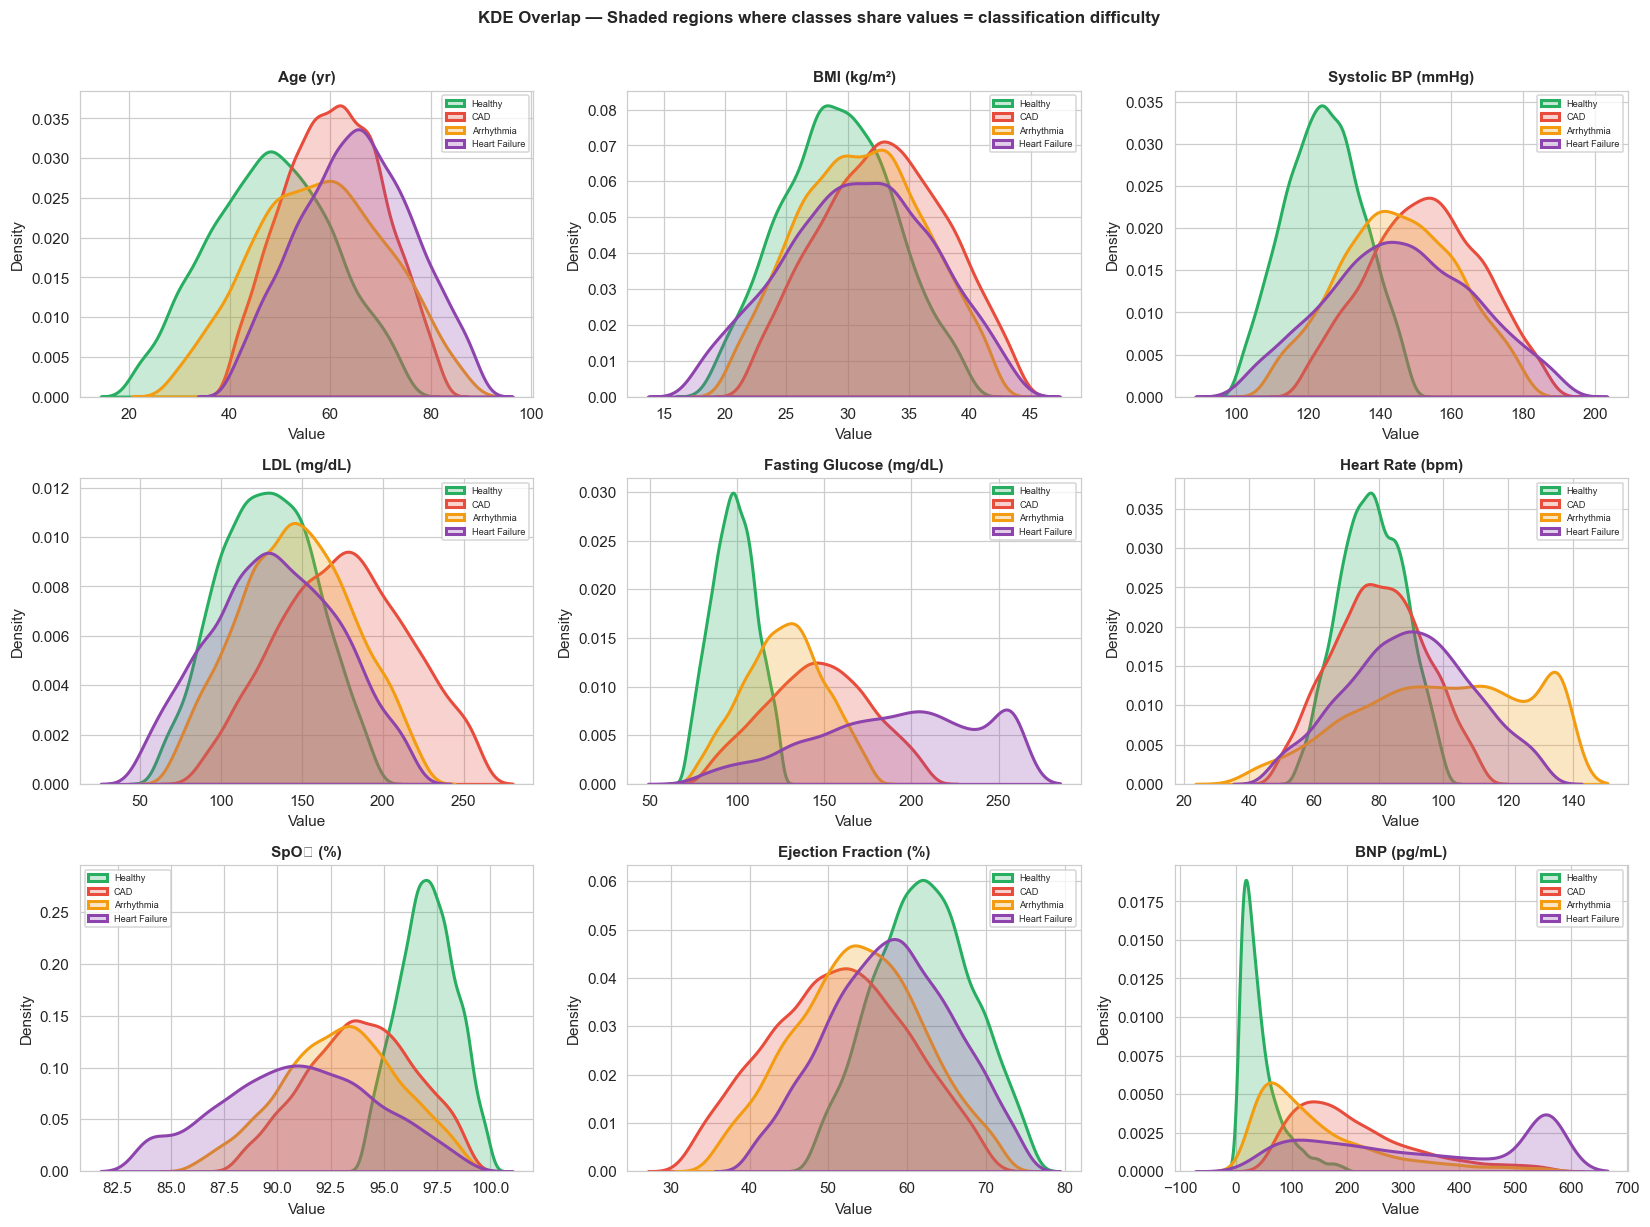

In [508]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
        subset = df.loc[df['target'] == cls, feat].dropna()
        sns.kdeplot(subset, ax=axes[i], label=cls, color=col,
                    fill=True, alpha=0.25, linewidth=2)
    axes[i].set_title(CONT_NICE[feat], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=6)

fig.suptitle('KDE Overlap — Shaded regions where classes share values = classification difficulty',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

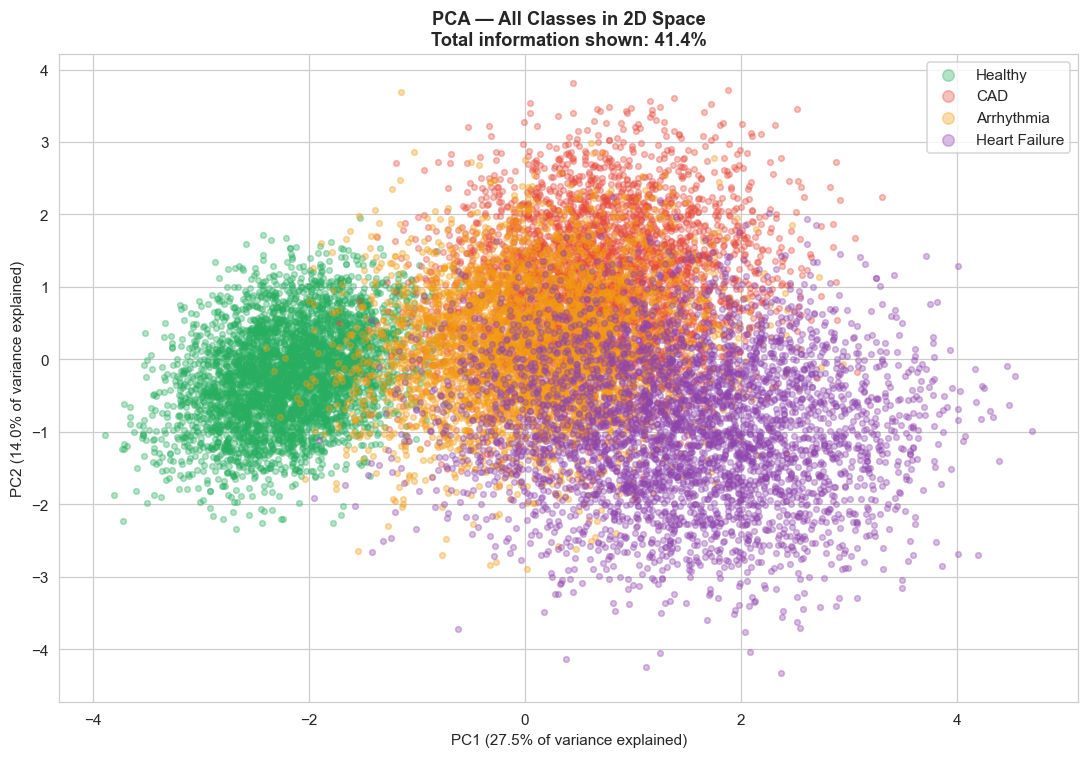

PC1 captures: 27.5 % of variance
PC2 captures: 14.0 % of variance
Total visible: 41.4 % of all information


In [509]:
X_for_pca = df[CONT_COLS].copy()
X_scaled   = StandardScaler().fit_transform(X_for_pca)

pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))

for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
    mask = df['target'] == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=col, alpha=0.35, s=14, label=cls)

ax.set_xlabel('PC1 (' + str(round(var[0], 1)) + '% of variance explained)')
ax.set_ylabel('PC2 (' + str(round(var[1], 1)) + '% of variance explained)')
ax.set_title('PCA — All Classes in 2D Space\nTotal information shown: ' + str(round(sum(var), 1)) + '%',
             fontweight='bold')
ax.legend(markerscale=2, fontsize=10)
plt.tight_layout()
plt.show()

print('PC1 captures:', round(var[0], 1), '% of variance')
print('PC2 captures:', round(var[1], 1), '% of variance')
print('Total visible:', round(sum(var), 1), '% of all information')

In [510]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate',
       'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking',
       'diabetes', 'edema', 'palpitations', 'ecg', 'target'],
      dtype='object')

## Modelling and Evaluation

In [511]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df.drop('target', axis=1)
y = df['target']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = ['sob','chest_tightness','smoking',
            'diabetes','edema','palpitations','ecg']

num_cols = X.columns.difference(cat_cols)

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

# keep categorical features unchanged
X_train_cat = X_train[cat_cols].values
X_test_cat = X_test[cat_cols].values

X_train_scaled = np.hstack([X_train_num, X_train_cat])
X_test_scaled = np.hstack([X_test_num, X_test_cat])

print("Shapes:")
print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)
print("Classes:", le.classes_)

Shapes:
Train: (12800, 16)
Test : (3200, 16)
Classes: ['Arrhythmia' 'CAD' 'Healthy' 'Heart Failure']


In [512]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


=== Logistic Regression (BASE) ===
CV Mean: 0.86171875
Train Acc: 0.863828125
Test Acc: 0.8678125
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       800
           1       0.80      0.81      0.81       800
           2       0.99      0.99      0.99       800
           3       0.87      0.87      0.87       800

    accuracy                           0.87      3200
   macro avg       0.87      0.87      0.87      3200
weighted avg       0.87      0.87      0.87      3200



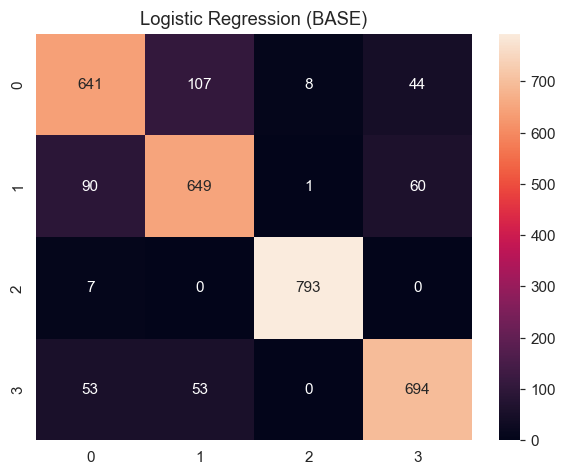

In [513]:
log_base = LogisticRegression(max_iter=1000, random_state=42)

log_cv = cross_val_score(log_base, X_train_scaled, y_train, cv=cv)

log_base.fit(X_train_scaled, y_train)

train_pred = log_base.predict(X_train_scaled)
test_pred  = log_base.predict(X_test_scaled)

print("\n=== Logistic Regression (BASE) ===")
print("CV Mean:", log_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d')
plt.title("Logistic Regression (BASE)")
plt.show()


=== Random Forest (BASE) ===
CV Mean: 0.8921875
Train Acc: 1.0
Test Acc: 0.8915625
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       800
           1       0.81      0.88      0.84       800
           2       0.99      1.00      1.00       800
           3       0.93      0.86      0.89       800

    accuracy                           0.89      3200
   macro avg       0.89      0.89      0.89      3200
weighted avg       0.89      0.89      0.89      3200



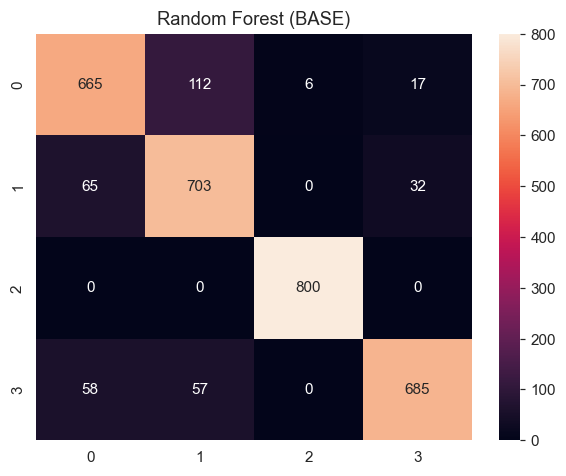

In [514]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_cv = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv)

rf_base.fit(X_train_scaled, y_train)

train_pred = rf_base.predict(X_train_scaled)
test_pred  = rf_base.predict(X_test_scaled)

print("\n=== Random Forest (BASE) ===")
print("CV Mean:", rf_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d')
plt.title("Random Forest (BASE)")
plt.show()


=== Decision Tree (BASE) ===
CV Mean: 0.821015625
Train Acc: 1.0
Test Acc: 0.8234375
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       800
           1       0.75      0.77      0.76       800
           2       0.98      0.98      0.98       800
           3       0.80      0.81      0.81       800

    accuracy                           0.82      3200
   macro avg       0.82      0.82      0.82      3200
weighted avg       0.82      0.82      0.82      3200



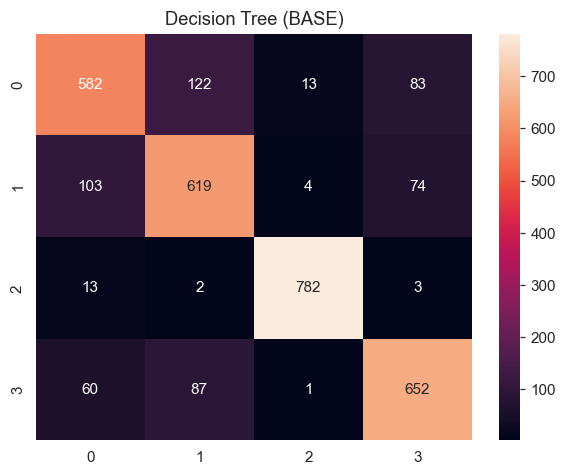

In [515]:
dt_base = DecisionTreeClassifier(random_state=42)

dt_cv = cross_val_score(dt_base, X_train_scaled, y_train, cv=cv)

dt_base.fit(X_train_scaled, y_train)

train_pred = dt_base.predict(X_train_scaled)
test_pred  = dt_base.predict(X_test_scaled)

print("\n=== Decision Tree (BASE) ===")
print("CV Mean:", dt_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d')
plt.title("Decision Tree (BASE)")
plt.show()


=== KNN (BASE) ===
CV Mean: 0.826953125
Train Acc: 0.880625
Test Acc: 0.8271875
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       800
           1       0.71      0.83      0.77       800
           2       0.96      1.00      0.98       800
           3       0.93      0.72      0.81       800

    accuracy                           0.83      3200
   macro avg       0.84      0.83      0.83      3200
weighted avg       0.84      0.83      0.83      3200



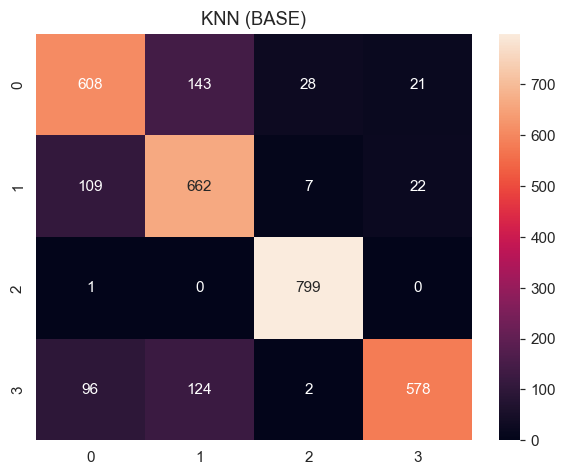

In [516]:
knn_base = KNeighborsClassifier()

knn_cv = cross_val_score(knn_base, X_train_scaled, y_train, cv=cv)

knn_base.fit(X_train_scaled, y_train)

train_pred = knn_base.predict(X_train_scaled)
test_pred  = knn_base.predict(X_test_scaled)

print("\n=== KNN (BASE) ===")
print("CV Mean:", knn_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d')
plt.title("KNN (BASE)")
plt.show()

## Hyper Parameter Tuning:

In [517]:
from sklearn.model_selection import RandomizedSearchCV

log_params = {"C": [0.01, 0.1, 1, 10]}

log_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_params,
    n_iter=4,
    cv=cv,
    scoring="accuracy",
    random_state=42
)

log_search.fit(X_train_scaled, y_train)
best_log = log_search.best_estimator_

In [518]:
knn_params = {"n_neighbors": [3,5,7,9,11]}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=5,
    cv=cv,
    scoring="accuracy",
    random_state=42
)

knn_search.fit(X_train_scaled, y_train)
best_knn = knn_search.best_estimator_

In [519]:
dt_params = {
    "max_depth": [5,10,15,None],
    "min_samples_split": [2,5,10]
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42
)

dt_search.fit(X_train_scaled, y_train)
best_dt = dt_search.best_estimator_

In [520]:
rf_params = {
    "n_estimators": [200,300,400],
    "max_depth": [10,12,15,None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42
)

rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_

In [521]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": best_log,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "Random Forest": best_rf
}

results = {}


for name, model in models.items():

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test, model.predict(X_test_scaled))

    gap = abs(train_acc - test_acc)

    results[name] = {
        "test_acc": test_acc,
        "gap": gap
    }

    print(name)
    print(" Train:", round(train_acc, 3))
    print(" Test :", round(test_acc, 3))
    print(" Gap  :", round(gap, 3))
    print("-"*40)

# TRUST SCORE (custom rule)
# lower gap = more trustworthy
# also prefer Logistic Regression if close

best_model = min(
    results,
    key=lambda x: (results[x]["gap"], -results[x]["test_acc"])
)

print(best_model)
print("Test Accuracy:", round(results[best_model]["test_acc"], 3))
print("Generalization Gap:", round(results[best_model]["gap"], 3))

Logistic Regression
 Train: 0.864
 Test : 0.868
 Gap  : 0.004
----------------------------------------
KNN
 Train: 0.869
 Test : 0.841
 Gap  : 0.029
----------------------------------------
Decision Tree
 Train: 0.935
 Test : 0.84
 Gap  : 0.096
----------------------------------------
Random Forest
 Train: 1.0
 Test : 0.894
 Gap  : 0.106
----------------------------------------
Logistic Regression
Test Accuracy: 0.868
Generalization Gap: 0.004


## Pickel the bezt model

In [522]:
import pickle

# best model (example: Logistic Regression)
best_model = best_log  

# save model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved")

Model and scaler saved
